# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("E:\AI\Data Analysis\Datasets\Sample - Superstore 2019.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2018-04-30 10:03:51.979187712,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,2018-05-04 09:03:29.645787392,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Postal Code,9983.0,55245.233297,1040.0,23223.0,57103.0,90008.0,99301.0,32038.715955
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


In [6]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [7]:
df.duplicated().sum()

0

# Data Cleaning

In [8]:
df[df.isnull().any(axis=1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2234,2235,CA-2019-104066,2019-12-05,2019-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,7,0.0,67.6599
5274,5275,CA-2017-162887,2017-11-07,2017-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,...,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,3,0.0,178.8000
8798,8799,US-2018-150140,2018-04-06,2018-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,...,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,5,0.0,336.6350
9146,9147,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2,0.0,42.9914
9147,9148,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,6,0.0,2.7336
9148,9149,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,13,0.0,406.7154
9386,9387,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,4,0.0,37.5624
9387,9388,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,1,0.0,5.7716
9388,9389,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,3,0.0,152.0232
9389,9390,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1,0.0,0.9588


In [9]:
df = df.drop(columns=['Postal Code'])

In [10]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [11]:
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

# Sales & Profit Analysis

In [12]:
Total_Sales = df['Sales'].sum()
print(f'Total_Sales = {round(Total_Sales,2)}')

Total_Sales = 2297200.86


In [13]:
Total_Profit = df['Profit'].sum()
print(f'Total_Profit = {round(Total_Profit,2)}')

Total_Profit = 286397.02


In [14]:
Total_Quantity = df['Quantity'].sum()
print(f'Total_Quantity : {Total_Quantity}')

Total_Quantity : 37873


In [15]:
Total_Orders = df['Order ID'].nunique()
print(f'Total_Orders : {Total_Orders}')

Total_Orders : 5009


In [16]:
Total_Customer = df['Customer ID'].nunique()
print(f'Total_Customer : {Total_Customer}')

Total_Customer : 793


In [17]:
print(f'Total_Sales = {round(Total_Sales,2)}')
print(f'Total_Profit = {round(Total_Profit,2)}')
print(f'Total_Quantity : {Total_Quantity}')
print(f'Total_Orders : {Total_Orders}')
print(f'Total_Customer : {Total_Customer}')

Total_Sales = 2297200.86
Total_Profit = 286397.02
Total_Quantity : 37873
Total_Orders : 5009
Total_Customer : 793


In [18]:
category_analysis = round(df.groupby('Category')[['Sales','Profit','Quantity']].sum(),2).sort_values(by='Sales',ascending =False)
category_analysis

,Sales,Profit,Quantity
Category,,,
Technology,836154.03,145454.95,6939
Furniture,741999.80,18451.27,8028
Office Supplies,719047.03,122490.80,22906


In [19]:
Profit_Margine = (df['Profit'].sum() / df['Sales'].sum()) *100
print(f'Profit_Margine : {Profit_Margine:.2f} %')

Profit_Margine : 12.47 %


In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [21]:
Category_Margine = (
    df.groupby('Category')[['Sales','Profit']].sum()
)
Category_Margine['Profit_Margine_%'] = (Category_Margine['Profit'] / Category_Margine['Sales']) *100

Category_Margine.sort_values(by='Profit_Margine_%', ascending=False).round(2)

,Sales,Profit,Profit_Margine_%
Category,,,
Technology,836154.03,145454.95,17.40
Office Supplies,719047.03,122490.80,17.04
Furniture,741999.80,18451.27,2.49


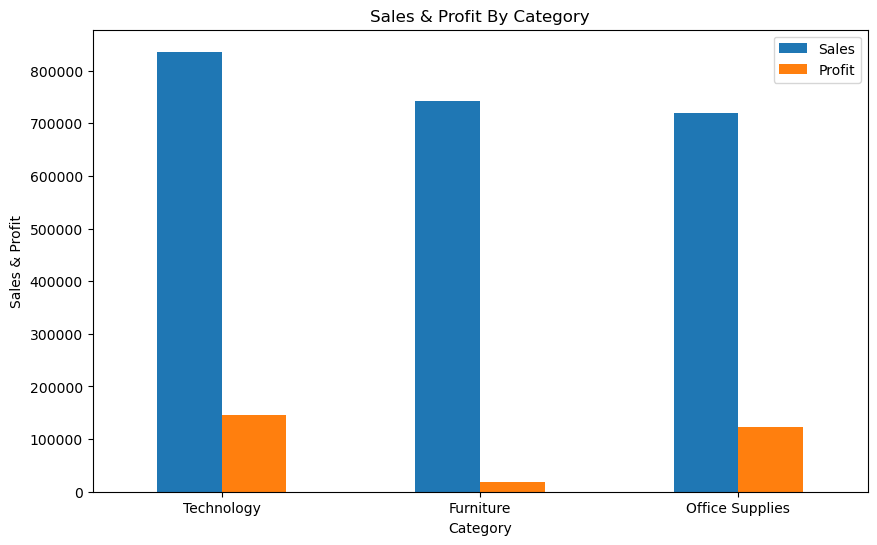

In [22]:
category_analysis_2 = round(df.groupby('Category')[['Sales','Profit']].sum(),2).sort_values(by='Sales',ascending =False)
category_analysis_2.plot(kind='bar',figsize = (10,6))

plt.title('Sales & Profit By Category'),
plt.xticks(rotation=0),
plt.xlabel('Category'),
plt.ylabel('Sales & Profit')
plt.show()

In [23]:
df['Discount'].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [24]:
discount_analysis = (
    df.groupby('Discount')[['Sales', 'Profit', 'Quantity']]
      .sum()
      .round(2)
)

discount_analysis

,Sales,Profit,Quantity
Discount,,,
0.00,1087908.47,320987.60,18267
0.10,54369.35,9029.18,373
0.15,27558.52,1418.99,198
0.20,764594.37,90337.31,13660
0.30,103226.66,-10369.28,849
0.32,14493.46,-2391.14,105
0.40,116417.78,-23057.05,786
0.45,5484.97,-2493.11,45
0.50,58918.54,-20506.43,241


In [25]:
discount_analysis['Profit_Margin_%'] = (
    discount_analysis['Profit'] /
    discount_analysis['Sales']
) * 100

discount_analysis.round(2)

,Sales,Profit,Quantity,Profit_Margin_%
Discount,,,,
0.00,1087908.47,320987.60,18267,29.51
0.10,54369.35,9029.18,373,16.61
0.15,27558.52,1418.99,198,5.15
0.20,764594.37,90337.31,13660,11.82
0.30,103226.66,-10369.28,849,-10.05
0.32,14493.46,-2391.14,105,-16.50
0.40,116417.78,-23057.05,786,-19.81
0.45,5484.97,-2493.11,45,-45.45
0.50,58918.54,-20506.43,241,-34.80


In [26]:
discount_category = (
    df.groupby(['Category', 'Discount'])['Profit'].sum().reset_index().round(2)
)

discount_category

,Category,Discount,Profit
0,Furniture,0.00,58133.08
1,Furniture,0.10,7111.01
2,Furniture,0.15,1418.99
3,Furniture,0.20,6265.95
4,Furniture,0.30,-10695.32
5,Furniture,0.32,-2391.14
6,Furniture,0.40,-16187.40
7,Furniture,0.45,-2493.11
8,Furniture,0.50,-12871.20
9,Furniture,0.60,-5944.66


In [27]:
Discount_Category_Margin = df.groupby(['Category', 'Discount'])[['Sales','Profit']].sum()
Discount_Category_Margin['Profitability'] = (Discount_Category_Margin['Profit'] / Discount_Category_Margin['Sales']) *100
Discount_Category_Margin.round(2)

Sales     Profit  Profitability
Category        Discount                                     
Furniture       0.00      256025.27   58133.08          22.71
                0.10       46634.25    7111.01          15.25
                0.15       27558.52    1418.99           5.15
                0.20      216631.02    6265.95           2.89
                0.30       99470.35  -10695.32         -10.75
                0.32       14493.46   -2391.14         -16.50
                0.40       45614.41  -16187.40         -35.49
                0.45        5484.97   -2493.11         -45.45
                0.50       20983.47  -12871.20         -61.34
                0.60        6644.70   -5944.66         -89.46
                0.70        2459.38   -3894.94        -158.37
Office Supplies 0.00      442150.00  130506.11          29.52
                0.10        4324.15    1086.08          25.12
                0.20      233049.74   38038.75          16.32
                0.70       22559.39  -16601.10         -73.59
                0.80       16963.76  -30539.04        -180.03
Technology      0.00      389733.20  132348.42          33.96
                0.10        3410.96     832.08          24.39
                0.20      314913.62   46032.61          14.62
                0.30        3756.30     326.04           8.68
                0.40       70803.38   -6869.65          -9.70
                0.50       37935.07   -7635.23         -20.13
                0.70       15601.51  -19579.32        -125.50

In [28]:
Discount_Category_Margin.sort_values(
    by='Profitability',
    ascending=False
).round(2)

Sales     Profit  Profitability
Category        Discount                                     
Technology      0.00      389733.20  132348.42          33.96
Office Supplies 0.00      442150.00  130506.11          29.52
                0.10        4324.15    1086.08          25.12
Technology      0.10        3410.96     832.08          24.39
Furniture       0.00      256025.27   58133.08          22.71
Office Supplies 0.20      233049.74   38038.75          16.32
Furniture       0.10       46634.25    7111.01          15.25
Technology      0.20      314913.62   46032.61          14.62
                0.30        3756.30     326.04           8.68
Furniture       0.15       27558.52    1418.99           5.15
                0.20      216631.02    6265.95           2.89
Technology      0.40       70803.38   -6869.65          -9.70
Furniture       0.30       99470.35  -10695.32         -10.75
                0.32       14493.46   -2391.14         -16.50
Technology      0.50       37935.07   -7635.23         -20.13
Furniture       0.40       45614.41  -16187.40         -35.49
                0.45        5484.97   -2493.11         -45.45
                0.50       20983.47  -12871.20         -61.34
Office Supplies 0.70       22559.39  -16601.10         -73.59
Furniture       0.60        6644.70   -5944.66         -89.46
Technology      0.70       15601.51  -19579.32        -125.50
Furniture       0.70        2459.38   -3894.94        -158.37
Office Supplies 0.80       16963.76  -30539.04        -180.03

# Customer Analysis

In [29]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [30]:
df['Customer ID'].nunique()

793

In [31]:
cust_anlysis = df.groupby(['Customer ID','Customer Name'])[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False).round(2)
cust_anlysis.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.05,-1980.74
TC-20980,Tamara Chand,19052.22,8981.32
RB-19360,Raymond Buch,15117.34,6976.10
TA-21385,Tom Ashbrook,14595.62,4703.79
AB-10105,Adrian Barton,14473.57,5444.81
KL-16645,Ken Lonsdale,14175.23,806.85
SC-20095,Sanjit Chand,14142.33,5757.41
HL-15040,Hunter Lopez,12873.30,5622.43
SE-20110,Sanjit Engle,12209.44,2650.68


In [32]:
cust_anlysis = df.groupby(['Customer ID','Customer Name'])[['Sales','Profit']].sum().sort_values(by='Profit', ascending=False).round(2)
cust_anlysis.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
TC-20980,Tamara Chand,19052.22,8981.32
RB-19360,Raymond Buch,15117.34,6976.10
SC-20095,Sanjit Chand,14142.33,5757.41
HL-15040,Hunter Lopez,12873.30,5622.43
AB-10105,Adrian Barton,14473.57,5444.81
TA-21385,Tom Ashbrook,14595.62,4703.79
CM-12385,Christopher Martinez,8954.02,3899.89
KD-16495,Keith Dawkins,8181.26,3038.63
AR-10540,Andy Reiter,6608.45,2884.62


In [33]:
sean = df[df['Customer Name'] == 'Sean Miller']
sean[['Order Date', 'Product Name', 'Category',
      'Sales', 'Quantity', 'Discount', 'Profit']]

,Order Date,Product Name,Category,Sales,Quantity,Discount,Profit
2266,2019-10-12,Xerox 1989,Office Supplies,7.968,2,0.2,2.6892
2573,2019-07-09,Eldon Antistatic Chair Mats for Low to Medium ...,Furniture,526.450,5,0.0,31.5870
2696,2016-03-18,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,Technology,821.300,4,0.5,-16.4260
2697,2016-03-18,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,6,0.5,-1811.0784
2698,2016-03-18,Xerox 195,Office Supplies,21.376,4,0.2,7.4816
2699,2016-03-18,Avery Fluorescent Highlighter Four-Color Set,Office Supplies,8.016,3,0.2,1.0020
2700,2016-03-18,"Executive Impressions 13"" Clairmont Wall Clock",Furniture,30.768,2,0.2,8.0766
2701,2016-03-18,Staples,Office Supplies,18.936,3,0.2,5.9175
2702,2016-03-18,"Dana Fluorescent Magnifying Lamp, White, 36""",Furniture,122.352,3,0.2,15.2940
7853,2017-12-25,Xerox 1949,Office Supplies,9.960,2,0.0,4.8804


In [34]:
sean[['Sales', 'Quantity', 'Profit']].sum().round(2)

Sales       25043.05
Quantity       50.00
Profit      -1980.74
dtype: float64

In [35]:
sean['Discount'].mean()

0.24666666666666673

In [36]:
sean[
    ['Order ID', 'Product Name', 'Category',
     'Sales', 'Quantity', 'Discount', 'Profit']
].sort_values(by='Profit')

,Order ID,Product Name,Category,Sales,Quantity,Discount,Profit
2697,CA-2016-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,6,0.5,-1811.0784
9189,US-2017-130512,"SAFCO Commercial Wire Shelving, Black",Office Supplies,663.072,6,0.2,-165.7680
9190,US-2017-130512,GBC DocuBind P100 Manual Binding Machine,Office Supplies,99.588,2,0.7,-82.9900
2696,CA-2016-145317,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,Technology,821.300,4,0.5,-16.4260
9187,US-2017-130512,Staple remover,Office Supplies,3.488,2,0.2,-0.6976
2699,CA-2016-145317,Avery Fluorescent Highlighter Four-Color Set,Office Supplies,8.016,3,0.2,1.0020
2266,CA-2019-149146,Xerox 1989,Office Supplies,7.968,2,0.2,2.6892
9188,US-2017-130512,Sabrent 4-Port USB 2.0 Hub,Technology,21.728,4,0.2,3.8024
7853,CA-2017-144890,Xerox 1949,Office Supplies,9.960,2,0.0,4.8804
2701,CA-2016-145317,Staples,Office Supplies,18.936,3,0.2,5.9175


In [37]:
loss_customers = (
    cust_anlysis[
        cust_anlysis['Profit'] < 0
    ]
    .sort_values(by='Sales', ascending=False)
)

loss_customers.head(10)


,,Sales,Profit
Customer ID,Customer Name,,
SM-20320,Sean Miller,25043.05,-1980.74
BM-11140,Becky Martin,11789.63,-1659.96
GT-14635,Grant Thornton,9351.21,-4108.66
PF-19120,Peter Fuller,9062.86,-614.29
NF-18385,Natalie Fritzler,8322.83,-1695.97
SB-20290,Sean Braxton,8057.89,-2082.75
ZC-21910,Zuschuss Carroll,8025.71,-1032.15
JH-15985,Joseph Holt,7955.00,-644.70
JA-15970,Joseph Airdo,6491.03,-819.42


In [38]:
loss_by_profit = (
    loss_customers
    .sort_values(by='Profit', ascending=True)
)

loss_by_profit.head(10)

,,Sales,Profit
Customer ID,Customer Name,,
CS-12505,Cindy Stewart,5690.06,-6626.39
GT-14635,Grant Thornton,9351.21,-4108.66
LF-17185,Luke Foster,3930.51,-3583.98
SR-20425,Sharelle Roach,3233.48,-3333.91
HG-14965,Henry Goldwyn,3247.64,-2797.96
NC-18415,Nathan Cano,2218.99,-2204.81
SB-20290,Sean Braxton,8057.89,-2082.75
SM-20320,Sean Miller,25043.05,-1980.74
CP-12340,Christine Phan,5888.28,-1850.30


In [39]:
loss_by_profit['Profit_Margin_%'] = (
    loss_by_profit['Profit'] /
    loss_by_profit['Sales']
) * 100

loss_by_profit.round(2).head(10)

,,Sales,Profit,Profit_Margin_%
Customer ID,Customer Name,,,
CS-12505,Cindy Stewart,5690.06,-6626.39,-116.46
GT-14635,Grant Thornton,9351.21,-4108.66,-43.94
LF-17185,Luke Foster,3930.51,-3583.98,-91.18
SR-20425,Sharelle Roach,3233.48,-3333.91,-103.11
HG-14965,Henry Goldwyn,3247.64,-2797.96,-86.15
NC-18415,Nathan Cano,2218.99,-2204.81,-99.36
SB-20290,Sean Braxton,8057.89,-2082.75,-25.85
SM-20320,Sean Miller,25043.05,-1980.74,-7.91
CP-12340,Christine Phan,5888.28,-1850.30,-31.42


In [40]:
customer_seg = (
    df.groupby(['Customer ID', 'Customer Name'])[['Sales', 'Profit']]
      .sum()
)

sales_avg = customer_seg['Sales'].mean()
profit_avg = customer_seg['Profit'].mean()

print(f"Average Sales: {sales_avg:.2f}")
print(f"Average Profit: {profit_avg:.2f}")

Average Sales: 2896.85
Average Profit: 361.16


In [41]:
def segment_customer(row):
    if row['Sales'] >= sales_avg and row['Profit'] >= profit_avg:
        return 'High Sales-High Profit'
    elif row['Sales'] >= sales_avg and row['Profit'] <= profit_avg:
        return 'High Sales-Low Profit'
    elif row['Sales'] <= sales_avg and row['Profit'] >= profit_avg:
        return 'Low Sales-High Profit'
    else:
        return 'Low Sales-Low Profit'
customer_seg['Segment'] = customer_seg.apply(segment_customer,axis=1)
customer_seg.head(10)

,,Sales,Profit,Segment
Customer ID,Customer Name,,,
AA-10315,Alex Avila,5563.560,-362.8825,High Sales-Low Profit
AA-10375,Allen Armold,1056.390,277.3824,Low Sales-Low Profit
AA-10480,Andrew Allen,1790.512,435.8274,Low Sales-High Profit
AA-10645,Anna Andreadi,5086.935,857.8033,High Sales-High Profit
AB-10015,Aaron Bergman,886.156,129.3465,Low Sales-Low Profit
AB-10060,Adam Bellavance,7755.620,2054.5885,High Sales-High Profit
AB-10105,Adrian Barton,14473.571,5444.8055,High Sales-High Profit
AB-10150,Aimee Bixby,966.710,313.6597,Low Sales-Low Profit
AB-10165,Alan Barnes,1113.838,220.8130,Low Sales-Low Profit


In [42]:
segment_analysis = (
    customer_seg
    .groupby('Segment')[['Sales', 'Profit']]
    .agg(['count', 'sum', 'mean'])
    .round(2)
)

segment_analysis

Sales                      Profit                    
                       count         sum     mean  count        sum     mean
Segment                                                                     
High Sales-High Profit   194  1110435.13  5723.89    194  248269.28  1279.74
High Sales-Low Profit    100   466101.10  4661.01    100  -38468.32  -384.68
Low Sales-High Profit     94   209341.01  2227.03     94   50454.38   536.75
Low Sales-Low Profit     405   511323.62  1262.53    405   26141.68    64.55

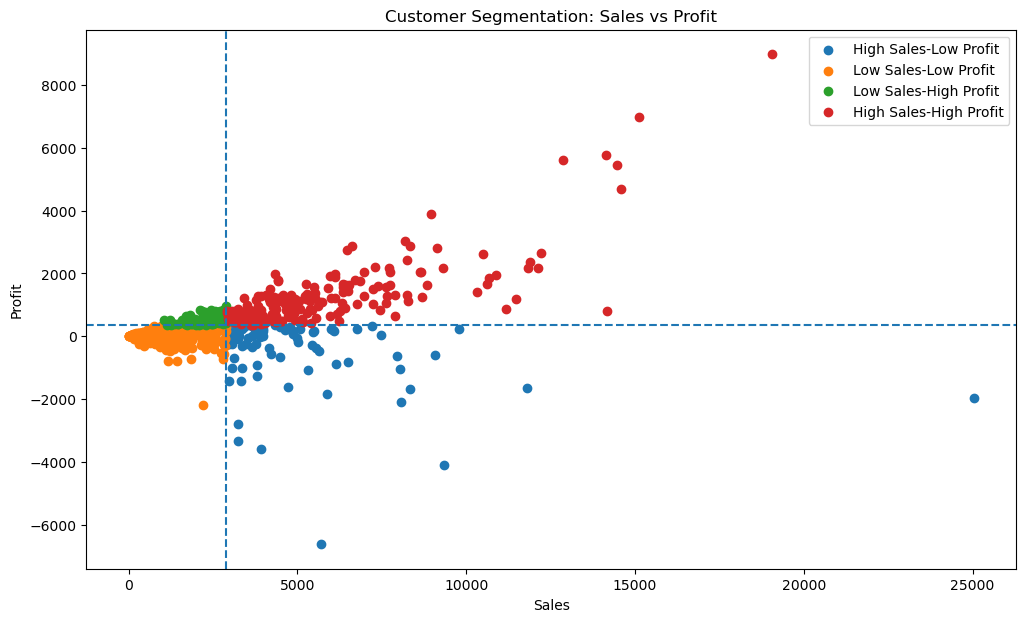

In [43]:
plt.figure(figsize=(12, 7))

for segment in customer_seg['Segment'].unique():
    data = customer_seg[customer_seg['Segment'] == segment]
    
    plt.scatter(
        data['Sales'],
        data['Profit'],
        label=segment
    )

plt.axvline(sales_avg, linestyle='--')
plt.axhline(profit_avg, linestyle='--')

plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Customer Segmentation: Sales vs Profit')
plt.legend()
plt.show()

In [44]:
segment_count = customer_seg['Segment'].value_counts()

segment_count

Segment
Low Sales-Low Profit      405
High Sales-High Profit    194
High Sales-Low Profit     100
Low Sales-High Profit      94
Name: count, dtype: int64

# Product Analysis

In [45]:
product_analysis = (
    df.groupby('Product Name')[['Sales', 'Profit', 'Quantity']]
      .sum()
      .round(2)
)
product_analysis.sort_values(by='Sales', ascending=False).head(10)

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,39
GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,48
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27


In [46]:
product_analysis = (
    df.groupby('Product Name')[['Sales', 'Profit', 'Quantity']]
      .sum()
      .round(2)
)
product_analysis.sort_values(by='Profit', ascending=False).head(10)

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,31
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,38
Canon PC1060 Personal Laser Copier,11619.83,4570.93,19
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,12
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,11
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,11
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28,24
Ibico EPK-21 Electric Binding System,15875.92,3345.28,13


In [47]:
loss_product = product_analysis[product_analysis['Profit']<0].sort_values(by='Profit',ascending=True).head(10)
loss_product

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,9
Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,18
Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.64,-2876.12,27
Bush Advantage Collection Racetrack Conference Table,9544.72,-1934.40,33
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,6
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18,22
Balt Solid Wood Round Tables,6518.75,-1201.06,19


In [48]:
df.to_csv(
    r'E:\AI\Data Analysis\Superstore_Analysis.csv',
    index=False
)